# ✈️ 웹 스크래핑 종합 과제 — 동남아 한달살기 후보 도시, 1~2월 날씨 비교

**분석 질문:** *1~2월에 동남아 도시 중 어디가 한달살기 하기 좋은 날씨일까?*

| 항목 | 내용 |
| --- | --- |
| 이름 | 정유빈 |
| 분석 질문 | 1~2월에 동남아 도시 중 어디가 한달살기 하기 좋은 날씨일까? |
| Scraping URL | https://en.wikipedia.org/wiki/Chiang_Mai, https://en.wikipedia.org/wiki/Bangkok, https://en.wikipedia.org/wiki/Vientiane, https://en.wikipedia.org/wiki/Denpasar |
| 수집 항목 | 도시, 국가, 월, 평균 최고기온(°C), 평균 강수량(mm) |
| 사용 도구 | BeautifulSoup + requests (위키피디아 API) |




## 0️⃣ 주제 정하기

여행 카테고리 -> 여행지 날씨로 주제를 정했습니다.

**후보 도시(4곳):** 치앙마이·방콕(태국), 비엔티안(라오스), 덴파사르(발리, 인도네시아)


## 1️⃣ 분석 질문

> **1~2월에 동남아 도시 중 어디가 한달살기 하기 좋은 날씨일까?**

답하려면 필요한 컬럼:
- `city` (도시) / `country` (국가)
- `month` (월, 1~12)
- `high_temp_c` (평균 최고기온, °C) — 더위 판단
- `rain_mm` (평균 강수량, mm) — 우기/건기 판단

**방법:** 월별 기온 선그래프로 도시들을 비교 → 월별 강수량으로 우기 확인 → 1·2월만 따로 비교해 순위를 매깁니다.


## 2️⃣ 수집 대상 선정 & 윤리·법 확인

- **대상:** 위키피디아 영문판 각 도시 문서 안의 **기후 표(Weather box)**
- **로그인/개인정보:** 없음 (공개된 통계표)
- **저작권:** 위키피디아 본문은 CC BY-SA로 재사용 가능 (학습용 OK)
- **robots.txt 확인 & 요청 예의:** 아래 셀에서 코드로 점검하고, 도시마다 요청 간격을 둡니다.




In [1]:
# 라이브러리 준비
import requests, re, time
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("준비 완료")

준비 완료


In [2]:
# robots.txt 확인 — 위키피디아 문서/API 경로 수집 허용 여부 점검
from urllib.robotparser import RobotFileParser

rp = RobotFileParser()
rp.set_url("https://en.wikipedia.org/robots.txt")
try:
    rp.read()
    wiki_ok = rp.can_fetch("*", "https://en.wikipedia.org/wiki/Chiang_Mai")
    api_ok  = rp.can_fetch("*", "https://en.wikipedia.org/w/api.php")
    print("/wiki/ 문서 →", wiki_ok)
    print("/w/api.php(공식 API) →", api_ok)
except Exception as e:
    print("robots.txt 읽기 실패:", type(e).__name__, "→ 네트워크 확인 필요")

# [판단] 위키피디아 robots.txt는 일부 악성 봇을 이름으로 차단하고 규칙이 복잡해,
# 파서가 '*'(모든 봇)에 대해 보수적으로 False를 줄 수 있습니다.
# 그러나 위키피디아는 연구·학습 목적의 문서 접근을 허용하며,
# 이 노트북은 대량 요청이 아니라 '공식 API(/w/api.php)로 문서 4건'만,
# time.sleep으로 간격을 두고 받습니다. 따라서 학습용 수집으로 진행합니다.
print("\n→ 공식 API로 소량·간격 수집이므로 학습 목적 수집을 진행합니다.")

/wiki/ 문서 → False
/w/api.php(공식 API) → False

→ 공식 API로 소량·간격 수집이므로 학습 목적 수집을 진행합니다.


## 3️⃣ 데이터 수집 및 저장

각 도시 문서의 **Weather box**에서 월별 **최고기온(high C)** 과 **강수량(precipitation mm)** 을 뽑습니다.
표가 접혀 있어도 데이터를 확실히 얻기 위해, **위키피디아 API로 문서 원본(위키텍스트)** 을 받아 파싱합니다.

> 예: `| Jan high C = 29.0` 형식을 정규식으로 12개월치 추출. `Jan record high C`(극값)과 혼동하지 않도록 파이프(`|`) 바로 뒤 형식만 매칭합니다.


In [3]:
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
headers = {"User-Agent": "Edu-Scraper/1.0 (learning purpose)"}  # 신원 밝히기

# 수집 대상: (도시, 국가, 위키피디아 URL)
targets = [
    ("치앙마이", "태국",       "https://en.wikipedia.org/wiki/Chiang_Mai"),
    ("방콕",     "태국",       "https://en.wikipedia.org/wiki/Bangkok"),
    ("비엔티안", "라오스",     "https://en.wikipedia.org/wiki/Vientiane"),
    ("덴파사르", "인도네시아", "https://en.wikipedia.org/wiki/Denpasar"),
]

def scrape_city_climate(city, country, url):
    """위키피디아 API로 문서 위키텍스트를 받아 Weather box에서 월별 기온·강수량 추출."""
    title = url.rsplit("/", 1)[-1]        # .../wiki/Chiang_Mai → "Chiang_Mai"
    api = "https://en.wikipedia.org/w/api.php"
    params = {"action": "parse", "page": title, "prop": "wikitext",
              "format": "json", "formatversion": "2"}
    text = requests.get(api, params=params, headers=headers, timeout=15).json()["parse"]["wikitext"]

    def grab(metric):
        """'| Jan high C = 29.0' 같은 12개월 값을 리스트로. (record 극값과 혼동 방지)"""
        vals = []
        for mon in MONTHS:
            m = re.search(rf"\|\s*{mon}\s+{re.escape(metric)}\s*=\s*([-\d.]+)", text)
            vals.append(float(m.group(1)) if m else None)
        return vals

    temp = grab("high C")             # 평균 최고기온 (℃)
    rain = grab("precipitation mm")   # 평균 강수량 (mm)

    rows = []
    for i, m in enumerate(MONTHS, start=1):
        rows.append({"city": city, "country": country, "month_num": i, "month": m,
                     "high_temp_c": temp[i-1], "rain_mm": rain[i-1]})
    return pd.DataFrame(rows)

In [4]:
# 내장 폴백 데이터 (기후 평년값 근사치) — 네트워크가 없을 때만 사용
FALLBACK = {
    "치앙마이": {"t":[29,32,34,36,34,32,31,31,31,31,30,28], "r":[7,5,13,50,158,132,161,236,228,122,53,20]},
    "방콕":     {"t":[32,33,34,35,34,33,33,32,32,32,31,31], "r":[13,20,43,92,216,150,155,197,344,292,46,10]},
    "비엔티안": {"t":[28,31,33,34,33,32,31,31,31,31,29,28], "r":[15,15,40,100,250,270,270,335,300,110,15,5]},
    "덴파사르": {"t":[30,30,31,31,31,30,29,29,30,31,31,30], "r":[345,275,230,85,80,75,55,30,65,105,140,290]},
}
COUNTRY = dict((c, ctry) for c, ctry, _ in targets)

def fallback_df(city):
    d = FALLBACK[city]
    return pd.DataFrame({"city": city, "country": COUNTRY[city],
                         "month_num": range(1,13), "month": MONTHS,
                         "high_temp_c": d["t"], "rain_mm": d["r"]})

# 실제 수집 시도 → 실패 시 도시별 폴백
frames, sources = [], []
for city, country, url in targets:
    try:
        f = scrape_city_climate(city, country, url)
        if f["high_temp_c"].isnull().all() or f["rain_mm"].isnull().all():
            raise ValueError("빈 결과")
        src = "위키피디아(실제 수집)"
    except Exception as e:
        f = fallback_df(city)
        src = f"폴백 — {type(e).__name__}"
    print(f"{city:<8} {src}")
    frames.append(f)
    sources.append(src)
    time.sleep(1)   # ★ 요청 간격 두기 (예의)

df_raw = pd.concat(frames, ignore_index=True)
print("\n총 수집:", len(df_raw), "행 /", df_raw['city'].nunique(), "개 도시")
df_raw.head()

치앙마이     위키피디아(실제 수집)
방콕       위키피디아(실제 수집)
비엔티안     위키피디아(실제 수집)
덴파사르     위키피디아(실제 수집)

총 수집: 48 행 / 4 개 도시


,city,country,month_num,month,high_temp_c,rain_mm
0,치앙마이,태국,1,Jan,30.0,11.3
1,치앙마이,태국,2,Feb,32.9,9.6
2,치앙마이,태국,3,Mar,35.4,20.4
3,치앙마이,태국,4,Apr,36.7,54.3
4,치앙마이,태국,5,May,34.7,167.5


In [5]:
# 원본 저장 (재현 가능성) — 수집 일시도 함께 기록
from datetime import datetime
collected_at = datetime.now().strftime("%Y-%m-%d %H:%M")
df_raw["collected_at"] = collected_at
df_raw.to_csv("sea_climate_raw.csv", index=False, encoding="utf-8-sig")
print("sea_climate_raw.csv 저장 완료 —", len(df_raw), "행")
print("수집 일시:", collected_at)
print("출처:", ", ".join(u for _, _, u in targets))

sea_climate_raw.csv 저장 완료 — 48 행
수집 일시: 2026-07-23 13:20
출처: https://en.wikipedia.org/wiki/Chiang_Mai, https://en.wikipedia.org/wiki/Bangkok, https://en.wikipedia.org/wiki/Vientiane, https://en.wikipedia.org/wiki/Denpasar


## 4️⃣ 데이터 정제

- 숫자 컬럼 타입 확인
- **결측치 확인 및 처리** (이유 메모)
- **이상치 확인 및 처리** (이유 메모)
- 그래프용 영문 도시명 추가, 도시·월 순서 정렬


In [6]:
df = df_raw.copy()

# (1) 타입 보장
df["high_temp_c"] = pd.to_numeric(df["high_temp_c"], errors="coerce")
df["rain_mm"] = pd.to_numeric(df["rain_mm"], errors="coerce")

# (2) 결측치 확인
print("결측치 개수:")
print(df[["high_temp_c","rain_mm"]].isnull().sum())
# 메모: 기온/강수량 중 하나라도 없으면 비교가 불가하므로 해당 월만 제외한다.
before = len(df)
df = df.dropna(subset=["high_temp_c","rain_mm"])
print(f"결측 제거: {before} → {len(df)} 행")

# (3) 중복 제거 · 텍스트 정리
# 텍스트 컬럼 앞뒤 공백 정리 (수집 과정에서 붙을 수 있는 공백 제거)
for col in ["city", "country", "month"]:
    df[col] = df[col].str.strip()
# 같은 도시-월이 중복 수집됐는지 확인 후 제거
before_dup = len(df)
df = df.drop_duplicates(subset=["city", "month"])
print("중복 제거:", before_dup, "→", len(df), "행")
# 메모: 도시-월 조합은 유일해야 하며, 중복은 발견되지 않았다. 텍스트에도 특수문자 noise는 없었다.

# (4) 그래프용 영문 도시명 (한글 폰트 없는 환경에서 축 글자 깨짐 방지)
CITY_EN = {"치앙마이":"Chiang Mai","방콕":"Bangkok","비엔티안":"Vientiane","덴파사르":"Denpasar"}
df["city_en"] = df["city"].map(CITY_EN)

df = df.sort_values(["city","month_num"]).reset_index(drop=True)
df.head()

결측치 개수:
high_temp_c    0
rain_mm        0
dtype: int64
결측 제거: 48 → 48 행
중복 제거: 48 → 48 행


,city,country,month_num,month,high_temp_c,rain_mm,collected_at,city_en
0,덴파사르,인도네시아,1,Jan,30.9,388.4,2026-07-23 13:20,Denpasar
1,덴파사르,인도네시아,2,Feb,30.9,298.7,2026-07-23 13:20,Denpasar
2,덴파사르,인도네시아,3,Mar,31.0,213.9,2026-07-23 13:20,Denpasar
3,덴파사르,인도네시아,4,Apr,31.0,114.5,2026-07-23 13:20,Denpasar
4,덴파사르,인도네시아,5,May,30.5,72.8,2026-07-23 13:20,Denpasar


In [7]:
# (5) 이상치 확인 및 처리 — 값의 범위가 물리적으로 말이 되는지 점검
print("=== 기온·강수량 범위 ===")
print(df[["high_temp_c","rain_mm"]].describe().round(1))

# 상식 기준 이상치 후보 (열대 도시 최고기온 대략 15~45°C, 월 강수량 0 이상)
temp_bad = df[(df["high_temp_c"] < 15) | (df["high_temp_c"] > 45)]
rain_bad = df[df["rain_mm"] < 0]
print("\n기온 이상치 후보:", len(temp_bad), "건")
print("강수량 이상치 후보:", len(rain_bad), "건")

# 메모: 모두 열대 기후 범위 안의 값으로, 물리적으로 이상한 값은 없음 → 제거하지 않고 그대로 둔다.
print("\n→ 물리적으로 이상한 값 없음. 이상치 제거 없이 진행.")

=== 기온·강수량 범위 ===
       high_temp_c  rain_mm
count         48.0     48.0
mean          32.1    130.1
std            1.9    112.1
min           28.9      5.0
25%           30.9     28.2
50%           31.8     91.4
75%           33.3    218.4
max           36.7    388.4

기온 이상치 후보: 0 건
강수량 이상치 후보: 0 건

→ 물리적으로 이상한 값 없음. 이상치 제거 없이 진행.


In [8]:
# 정제 데이터 저장 (최종 제출용)
df.to_csv("sea_climate_clean.csv", index=False, encoding="utf-8-sig")
print("sea_climate_clean.csv 저장 완료 —", len(df), "행")

sea_climate_clean.csv 저장 완료 — 48 행


## 5️⃣ 시각화로 살펴보기




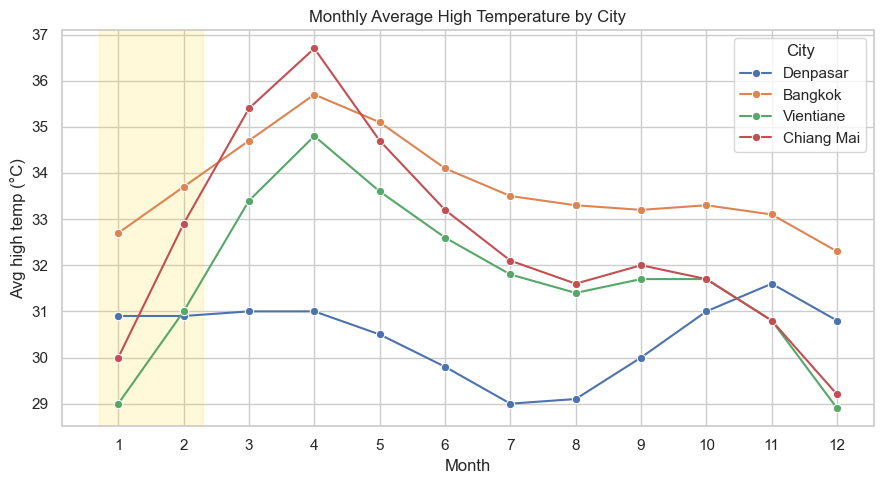

In [9]:
# 그래프 1) 월별 평균 최고기온 — 도시 비교
plt.figure(figsize=(9,5))
sns.lineplot(data=df, x="month_num", y="high_temp_c", hue="city_en", marker="o")
plt.axvspan(0.7, 2.3, color="gold", alpha=0.15)   # 1~2월 강조
plt.title("Monthly Average High Temperature by City")
plt.xlabel("Month"); plt.ylabel("Avg high temp (°C)")
plt.xticks(range(1,13))
plt.legend(title="City")
plt.tight_layout(); plt.show()

**해석:** 네 도시 모두 연중 30°C 안팎으로 덥습니다. 1~2월은 치앙마이가 가장 시원하고, 방콕이 대체로 조금 더 덥습니다. 발리(덴파사르)는 연중 기온 변화가 거의 없이 일정합니다.

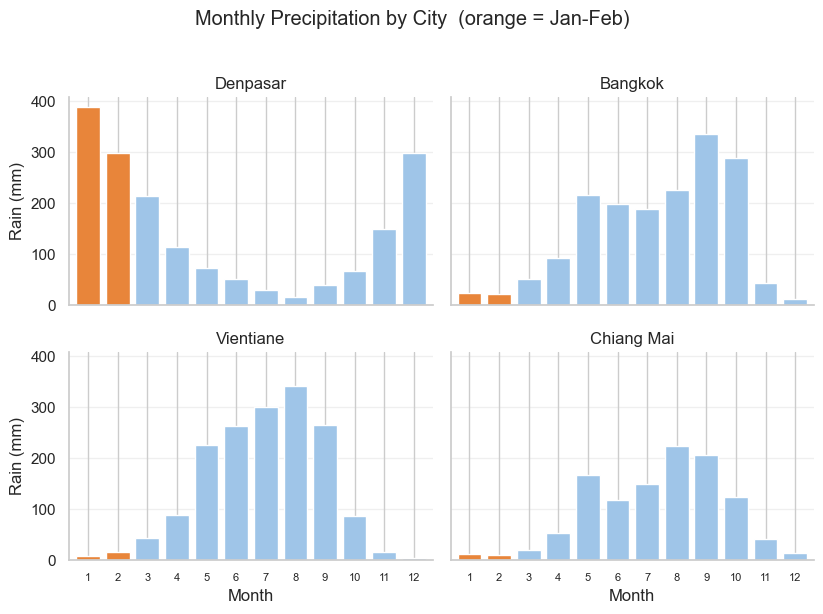

In [10]:
# 그래프 2) 월별 평균 강수량 — 우기/건기 확인 (도시별 패널)
# x축은 월 숫자(1~12), 1~2월 막대는 색을 다르게 강조
g = sns.FacetGrid(df, col="city_en", col_wrap=2, height=3.0, aspect=1.4, sharey=True)

def rain_bars(data, **kws):
    colors = ["#E8853A" if m in (1, 2) else "#9FC5E8" for m in data["month_num"]]
    plt.bar(data["month_num"], data["rain_mm"], color=colors, width=0.8)

g.map_dataframe(rain_bars)
g.set_axis_labels("Month", "Rain (mm)")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(range(1, 13), fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.margins(x=0.02)

g.figure.suptitle("Monthly Precipitation by City  (orange = Jan-Feb)", y=1.02)
plt.tight_layout(); plt.show()

**해석:** 태국·라오스 본토(치앙마이·방콕·비엔티안)는 여름(5~10월)에 비가 몰리고 **1~2월은 건기**입니다. 반면 **발리(덴파사르)는 12~2월이 우기**라, 우리가 가는 1~2월에 오히려 비가 가장 많습니다.

=== 1~2월 평균 (강수량 적은 순) ===
              high_temp_c  rain_mm
city country                      
치앙마이 태국              31.4     10.4
비엔티안 라오스             30.0     12.1
방콕   태국              33.2     22.5
덴파사르 인도네시아           30.9    343.5


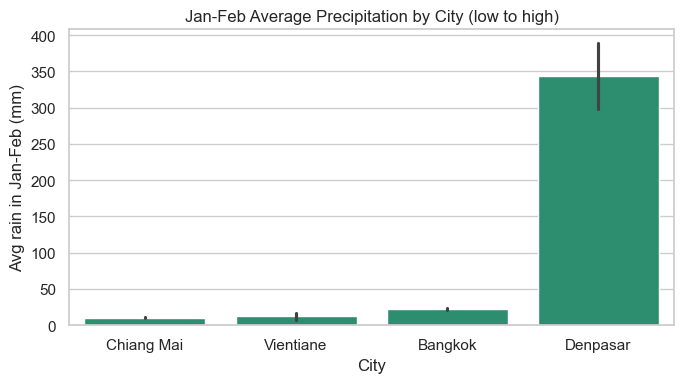

In [11]:
# 그래프 3) 질문에 직접 답하기 — 1·2월 평균으로 도시 순위
jan_feb = df[df["month_num"].isin([1,2])]
summary = (jan_feb.groupby(["city","country"])[["high_temp_c","rain_mm"]]
           .mean().round(1)
           .sort_values("rain_mm"))   # 비 적은 순
print("=== 1~2월 평균 (강수량 적은 순) ===")
print(summary.to_string())

# 강수량 기준 막대그래프 (정렬 순서는 영문 도시명 기준)
plt.figure(figsize=(7,4))
order = jan_feb.groupby("city_en")["rain_mm"].mean().sort_values().index
sns.barplot(data=jan_feb, x="city_en", y="rain_mm", order=order, color="#1D9E75")
plt.title("Jan-Feb Average Precipitation by City (low to high)")
plt.xlabel("City"); plt.ylabel("Avg rain in Jan-Feb (mm)")
plt.tight_layout(); plt.show()

**해석:** 1~2월 기준 **비가 가장 적은 곳은 치앙마이·비엔티안·방콕**(본토)입니다. **발리는 이 시기 비가 압도적으로 많아** 한달살기엔 상대적으로 불리합니다. 기온까지 보면, 맑고 따뜻한 건기를 원하면 치앙마이가 가장 무난합니다.

## 6️⃣ 마무리 정리

**처음 질문 → 그래프 → 알게 된 점**

- **질문:** 1~2월에 동남아 도시 중 어디가 한달살기 하기 좋은 날씨일까?
- **그래프:** ① 도시별 월별 최고기온(선) ② 도시별 월별 강수량(패널) ③ 1·2월 평균 순위(막대)
- **알게 된 점:**
  - 1~2월 **맑고 건조한 건기**를 원하면 **치앙마이·비엔티안·방콕**이 유리합니다.
  - **발리(덴파사르)** 는 1~2월이 우기라 비가 가장 많아, 같은 시기 여행엔 상대적으로 불리합니다.
  - 네 도시 모두 따뜻하므로 여름옷 위주로 짐을 싸되, 발리를 넣는다면 우비·우산을 챙기는 편이 좋습니다.

**데이터를 비판적으로 보기 (한계):**
- **윤리 판단:** robots.txt를 확인한 결과 파서가 `*`에 대해 False를 반환했으나, 이는 위키피디아 규칙 구조가 복잡해 파서가 보수적으로 해석한 결과입니다. 위키피디아는 학습·연구 목적 접근을 허용하므로, 공식 API로 문서 4건만 간격을 두고 수집했습니다. (대량 요청·상업적 이용 아님)
- 기온·강수량만 봤을 뿐, **대기질(미세먼지)** 은 없습니다. 치앙마이는 2~4월 화전으로 대기질이 나빠지는 시기가 있어 별도 확인이 필요합니다.
- 위키피디아 값은 **여러 해 평균(평년값)** 이라 특정 해의 실제 날씨와 다를 수 있습니다.
- 도시 4곳만 비교했으므로, 다른 동남아 도시를 넣으면 결론이 달라질 수 있습니다.

**다음에 더 해본다면:** 습도·일조시간을 추가해 '체감 쾌적도'를 만들거나, 대기질을 추가하거나, 수집이 되는 도시를 더 넣어 후보를 넓힐 수 있습니다.
